## File Loading and Frequency-Grid Checks


In [25]:
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from IPython.display import Markdown, display

base_dir_candidates = [Path("Al2O3_Al_athermal"), Path("wk6/Al2O3_Al_athermal")]
base_dir = next((path for path in base_dir_candidates if path.exists()), None)
if base_dir is None:
    raise FileNotFoundError("Could not find the Al2O3_Al_athermal directory from the current working directory.")

noise_files = {
    "Total noise": base_dir / "total_noise.dat",
    "SQUID noise": base_dir / "SQUID_noise.dat",
    "Er noise": base_dir / "Er_noise.dat",
    "TD noise": base_dir / "TD_noise.dat",
    "Johnson noise": base_dir / "Johnson_noise.dat",
}
mmc_path = Path("/ceph/dwong/delight_conf/new/noise_psd_xray.npy")

spectra = {label: np.loadtxt(path) for label, path in noise_files.items()}
mmc_data = np.load(mmc_path)

if mmc_data.ndim == 2 and mmc_data.shape[0] == 2:
    mmc_freq, mmc_raw_spectrum = mmc_data
else:
    sampling_frequency = 3_906_250
    mmc_raw_spectrum = np.ravel(mmc_data)
    mmc_freq = np.linspace(0.0, sampling_frequency / 2, mmc_raw_spectrum.size)


def summarize_frequency_axis(label, frequencies):
    diffs = np.diff(frequencies)
    print(
        f"{label}: bins={frequencies.size}, range=[{frequencies[0]:.6g}, {frequencies[-1]:.6g}] Hz, "
        f"interval(min/median/max)=[{diffs.min():.6g}, {np.median(diffs):.6g}, {diffs.max():.6g}] Hz"
    )


print("Frequency bin summary:")
reference_freq = next(iter(spectra.values()))[:, 0]
for label, spectrum in spectra.items():
    summarize_frequency_axis(label, spectrum[:, 0])
summarize_frequency_axis("MMC raw spectrum", mmc_freq)

same_range = np.isclose(reference_freq[0], mmc_freq[0]) and np.isclose(reference_freq[-1], mmc_freq[-1])
same_bins = reference_freq.size == mmc_freq.size and np.allclose(reference_freq, mmc_freq[: reference_freq.size])
print(f"MMC frequency range matches AL2O3/AL files: {same_range}")
print(f"MMC frequency bins match AL2O3/AL files: {same_bins}")


Frequency bin summary:
Total noise: bins=16384, range=[1, 3e+07] Hz, interval(min/median/max)=[0.00105144, 5.75595, 31510.1] Hz
SQUID noise: bins=16384, range=[1, 3e+07] Hz, interval(min/median/max)=[0.00105144, 5.75595, 31510.1] Hz
Er noise: bins=16384, range=[1, 3e+07] Hz, interval(min/median/max)=[0.00105144, 5.75595, 31510.1] Hz
TD noise: bins=16384, range=[1, 3e+07] Hz, interval(min/median/max)=[0.00105144, 5.75595, 31510.1] Hz
Johnson noise: bins=16384, range=[1, 3e+07] Hz, interval(min/median/max)=[0.00105144, 5.75595, 31510.1] Hz
MMC raw spectrum: bins=16385, range=[0, 1.95313e+06] Hz, interval(min/median/max)=[119.209, 119.209, 119.209] Hz
MMC frequency range matches AL2O3/AL files: False
MMC frequency bins match AL2O3/AL files: False


## Raw Native-Spectrum Inspection

This figure mixes:
- verified AL ASD-like spectra from the professor-derived AL files
- MMC raw uploaded spectrum with still-unverified physical meaning

Therefore this plot is for visual inspection of stored shapes and frequency coverage only, not for quantitative amplitude comparison.


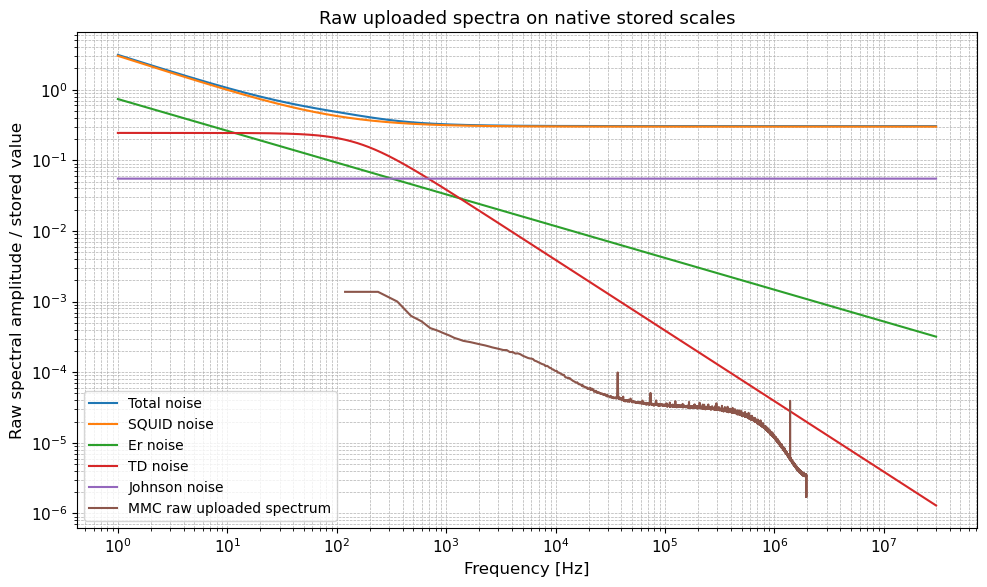

In [26]:
plt.figure(figsize=(10, 6))

for label, spectrum in spectra.items():
    frequencies = spectrum[:, 0]
    raw_spectrum = spectrum[:, 1]
    valid = (frequencies > 0) & (raw_spectrum > 0)
    plt.loglog(frequencies[valid], raw_spectrum[valid], label=label, linewidth=1.5)

valid_mmc = (mmc_freq > 0) & (mmc_raw_spectrum > 0)
plt.loglog(
    mmc_freq[valid_mmc],
    mmc_raw_spectrum[valid_mmc],
    label="MMC raw uploaded spectrum",
    linestyle="-",
    linewidth=1.5,
)

plt.title("Raw uploaded spectra on native stored scales")
plt.xlabel("Frequency [Hz]")
plt.ylabel("Raw spectral amplitude / stored value")
plt.grid(True, which="both", linestyle="--", linewidth=0.5)
plt.legend()
plt.tight_layout()
plt.show()


## Verified Interpretation of AL Curves as ASD

total_noise.dat, SQUID_noise.dat, Er_noise.dat, TD_noise.dat, and Johnson_noise.dat are all treated as ASD curves because they originate from the professor's plot with y-axis sqrt(S_phi) / microPhi0 / sqrt(Hz).
Under the working convention microPhi0 -> microV, these become ASD in microV / sqrt(Hz).
PSD is constructed only after squaring the ASD.


## AL Quadrature-Sum Validation

The pass/fail thresholds used below are workflow sanity checks only. They are not physics-derived acceptance criteria.


AL quadrature-sum validation on native AL frequency grid:
median(total_asd/model_asd) = 1.000000
max fractional deviation    = 0.000000
RMS fractional deviation    = 0.000000


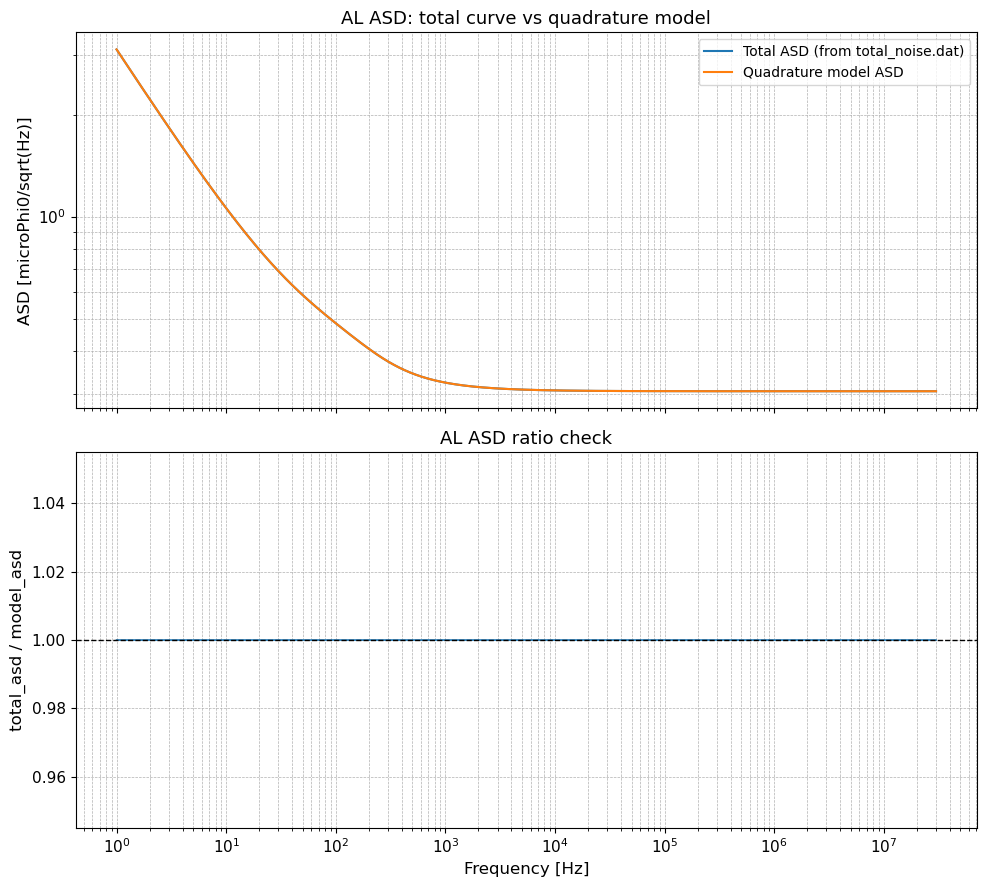

In [27]:
al_freq = spectra["Total noise"][:, 0]

def require_common_al_grid(label, spectrum):
    f = spectrum[:, 0]
    if f.size != al_freq.size or not np.allclose(f, al_freq):
        raise ValueError(f"{label} is not on the same AL frequency grid as Total noise.")

for label, spectrum in spectra.items():
    require_common_al_grid(label, spectrum)

asd_total = spectra["Total noise"][:, 1]
asd_er = spectra["Er noise"][:, 1]
asd_johnson = spectra["Johnson noise"][:, 1]
asd_squid = spectra["SQUID noise"][:, 1]
asd_td = spectra["TD noise"][:, 1]

asd_model_sq = asd_er**2 + asd_johnson**2 + asd_squid**2 + asd_td**2
asd_model = np.sqrt(asd_model_sq)

valid = (al_freq > 0) & np.isfinite(asd_total) & np.isfinite(asd_model) & (asd_total > 0) & (asd_model > 0)
ratio = asd_total[valid] / asd_model[valid]
frac_dev = np.abs(ratio - 1.0)

median_ratio = np.median(ratio)
max_frac_dev = np.max(frac_dev)
rms_frac_dev = np.sqrt(np.mean((ratio - 1.0) ** 2))

print("AL quadrature-sum validation on native AL frequency grid:")
print(f"median(total_asd/model_asd) = {median_ratio:.6f}")
print(f"max fractional deviation    = {max_frac_dev:.6f}")
print(f"RMS fractional deviation    = {rms_frac_dev:.6f}")

fig_study_a_quadrature, axes = plt.subplots(2, 1, figsize=(10, 9), sharex=True)
axes[0].loglog(al_freq[valid], asd_total[valid], label="Total ASD (from total_noise.dat)", linewidth=1.5)
axes[0].loglog(al_freq[valid], asd_model[valid], label="Quadrature model ASD", linewidth=1.5)
axes[0].set_ylabel("ASD [microPhi0/sqrt(Hz)]")
axes[0].set_title("AL ASD: total curve vs quadrature model")
axes[0].grid(True, which="both", linestyle="--", linewidth=0.5)
axes[0].legend()

axes[1].semilogx(al_freq[valid], ratio, linewidth=1.2)
axes[1].axhline(1.0, color="k", linestyle="--", linewidth=1.0)
axes[1].set_xlabel("Frequency [Hz]")
axes[1].set_ylabel("total_asd / model_asd")
axes[1].set_title("AL ASD ratio check")
axes[1].grid(True, which="both", linestyle="--", linewidth=0.5)

fig_study_a_quadrature.tight_layout()
fig_study_a_quadrature.savefig("studyA_quadrature_validation_AL.pdf")
fig_study_a_quadrature.savefig("studyA_quadrature_validation_AL.png", dpi=300)
plt.show()

AL_BAD_MISMATCH_MAX_FRAC_DEV = 0.50
AL_BAD_MISMATCH_RMS_FRAC_DEV = 0.20
al_quadrature_validation_passed = (
    max_frac_dev <= AL_BAD_MISMATCH_MAX_FRAC_DEV and rms_frac_dev <= AL_BAD_MISMATCH_RMS_FRAC_DEV
)

if not al_quadrature_validation_passed:
    raise RuntimeError(
        "AL quadrature validation failed badly. Stop interpretation and verify component definitions/scales before proceeding. "
        f"Observed max_frac_dev={max_frac_dev:.6f}, rms_frac_dev={rms_frac_dev:.6f}."
    )


## Harmonized AL ASD -> PSD Conversion in Common microV Units


In [28]:
AL_ASD_MICROPHI_TO_MICROVOLT = 1.0


def integrate_psd_trapezoid(frequencies, psd_values):
    valid = (frequencies > 0) & np.isfinite(psd_values) & (psd_values >= 0)
    return np.trapz(psd_values[valid], frequencies[valid]), int(np.count_nonzero(valid))


valid_mmc = (mmc_freq > 0) & np.isfinite(mmc_raw_spectrum) & (mmc_raw_spectrum >= 0)
common_freq = mmc_freq[valid_mmc]
common_mmc_psd_assumed = mmc_raw_spectrum[valid_mmc]

print("Aligned comparison band on common_freq:")
print(f"- minimum frequency [Hz]: {common_freq[0]:.6g}")
print(f"- maximum frequency [Hz]: {common_freq[-1]:.6g}")
print(f"- number of bins: {common_freq.size}")

aligned_psd_map = {"MMC raw (assumed PSD)": common_mmc_psd_assumed}
aligned_results = []

mmc_variance_microvolt2_assumed, mmc_finite_bins_used = integrate_psd_trapezoid(common_freq, common_mmc_psd_assumed)
aligned_results.append(
    ("MMC raw (assumed PSD)", mmc_variance_microvolt2_assumed, np.sqrt(mmc_variance_microvolt2_assumed), mmc_finite_bins_used)
)

print("Finite bins used for numerical trapezoidal integration of aligned AL PSDs:")
for label, spectrum in spectra.items():
    frequencies = spectrum[:, 0]
    asd_microvolt = spectrum[:, 1] * AL_ASD_MICROPHI_TO_MICROVOLT
    psd_microvolt2 = asd_microvolt**2
    aligned_psd = np.interp(common_freq, frequencies, psd_microvolt2, left=np.nan, right=np.nan)
    aligned_label = f"{label} (AL ASD->PSD)"
    aligned_psd_map[aligned_label] = aligned_psd
    variance, finite_bins_used = integrate_psd_trapezoid(common_freq, aligned_psd)
    aligned_results.append((aligned_label, variance, np.sqrt(variance), finite_bins_used))
    print(f"- {aligned_label}: {finite_bins_used} finite bins")


Aligned comparison band on common_freq:
- minimum frequency [Hz]: 119.209
- maximum frequency [Hz]: 1.95313e+06
- number of bins: 16384
Finite bins used for numerical trapezoidal integration of aligned AL PSDs:
- Total noise (AL ASD->PSD): 16384 finite bins
- SQUID noise (AL ASD->PSD): 16384 finite bins
- Er noise (AL ASD->PSD): 16384 finite bins
- TD noise (AL ASD->PSD): 16384 finite bins
- Johnson noise (AL ASD->PSD): 16384 finite bins


## Study A (AL-Only): Noise Budget Decomposition

This branch uses AL spectra only on the verified ASD interpretation. MMC is intentionally excluded from the validated Study A conclusions.


In [29]:
# AL-only Study A inputs on native AL grid
psd_total = asd_total**2
psd_er = asd_er**2
psd_johnson = asd_johnson**2
psd_squid = asd_squid**2
psd_td = asd_td**2

study_a_psd_components = {
    "Er": psd_er,
    "Johnson": psd_johnson,
    "SQUID": psd_squid,
    "TD": psd_td,
}

study_a_asd_components = {
    "Total": asd_total,
    "SQUID": asd_squid,
    "Johnson": asd_johnson,
    "TD": asd_td,
    "Er": asd_er,
}


## Study A Overview Figure (AL Component Budget)


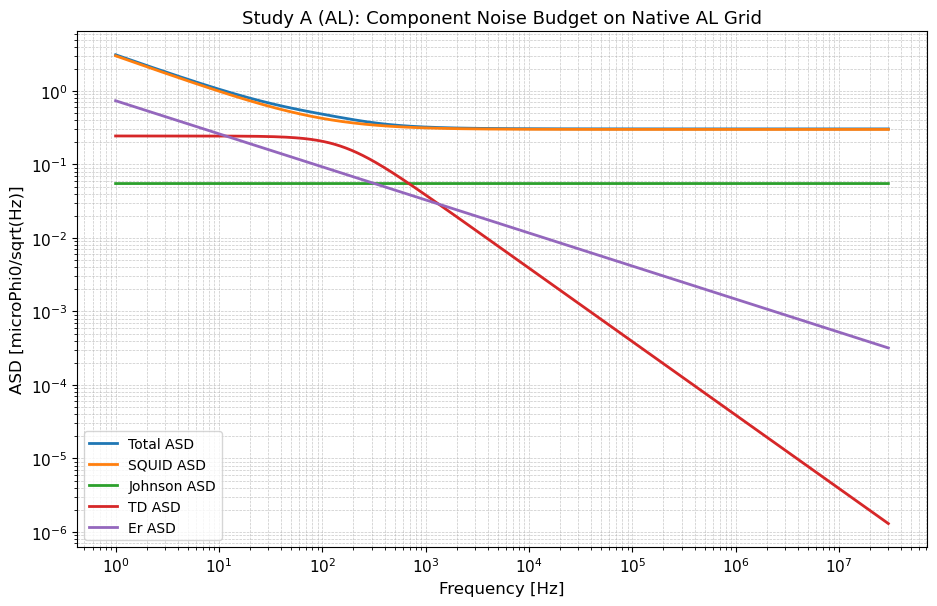

In [30]:
# Report-quality AL component overview figure (ASD)
plt.rcParams.update({
    "font.size": 11,
    "axes.titlesize": 13,
    "axes.labelsize": 12,
    "legend.fontsize": 10,
})

valid_al_plot = (al_freq > 0)
fig_study_a_overview, ax = plt.subplots(figsize=(9.5, 6.2))

plot_order = ["Total", "SQUID", "Johnson", "TD", "Er"]
for key in plot_order:
    y = study_a_asd_components[key]
    valid = valid_al_plot & np.isfinite(y) & (y > 0)
    ax.loglog(al_freq[valid], y[valid], linewidth=2.0, label=f"{key} ASD")

ax.set_title("Study A (AL): Component Noise Budget on Native AL Grid")
ax.set_xlabel("Frequency [Hz]")
ax.set_ylabel("ASD [microPhi0/sqrt(Hz)]")
ax.grid(True, which="both", linestyle="--", linewidth=0.5, alpha=0.7)
ax.legend(loc="best", frameon=True)
fig_study_a_overview.tight_layout()
fig_study_a_overview.savefig("studyA_overview_AL.pdf")
fig_study_a_overview.savefig("studyA_overview_AL.png", dpi=300)
plt.show()


## Study A Fractional Contributions vs Frequency

Fractional contribution definitions on AL grid:

R_i(f) = N_i^2(f) / N_total^2(f)


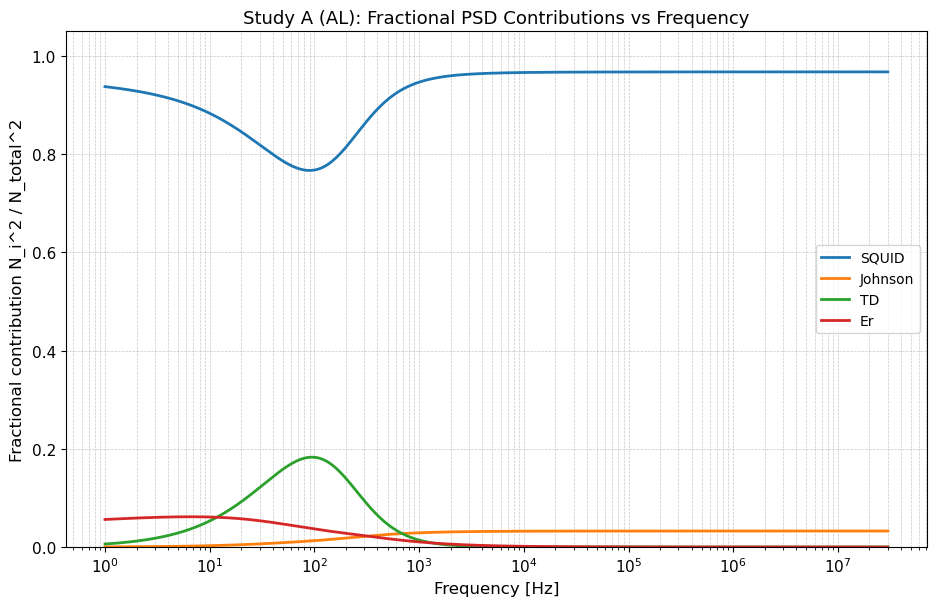

In [31]:
valid_psd_total = (al_freq > 0) & np.isfinite(psd_total) & (psd_total > 0)

def fractional_contribution(component_psd, total_psd, valid_mask):
    out = np.full_like(total_psd, np.nan, dtype=float)
    valid = valid_mask & np.isfinite(component_psd) & (component_psd >= 0)
    out[valid] = component_psd[valid] / total_psd[valid]
    return out

R_er = fractional_contribution(psd_er, psd_total, valid_psd_total)
R_johnson = fractional_contribution(psd_johnson, psd_total, valid_psd_total)
R_squid = fractional_contribution(psd_squid, psd_total, valid_psd_total)
R_td = fractional_contribution(psd_td, psd_total, valid_psd_total)

study_a_fraction_map = {
    "Er": R_er,
    "Johnson": R_johnson,
    "SQUID": R_squid,
    "TD": R_td,
}

fig_study_a_fractional, ax = plt.subplots(figsize=(9.5, 6.2))
for label in ["SQUID", "Johnson", "TD", "Er"]:
    r = study_a_fraction_map[label]
    valid = (al_freq > 0) & np.isfinite(r) & (r >= 0)
    ax.semilogx(al_freq[valid], r[valid], linewidth=2.0, label=label)

ax.set_title("Study A (AL): Fractional PSD Contributions vs Frequency")
ax.set_xlabel("Frequency [Hz]")
ax.set_ylabel("Fractional contribution N_i^2 / N_total^2")
ax.set_ylim(0.0, 1.05)
ax.grid(True, which="both", linestyle="--", linewidth=0.5, alpha=0.7)
ax.legend(loc="best", frameon=True)
fig_study_a_fractional.tight_layout()
fig_study_a_fractional.savefig("studyA_fractional_contributions_AL.pdf")
fig_study_a_fractional.savefig("studyA_fractional_contributions_AL.png", dpi=300)
plt.show()


## Study A Band-Dominance Summary (AL Grid)

Classification convention used in Study A interpretation:

- readout-limited uses SQUID + TD
- device-limited uses Johnson + Er
- this is a bookkeeping convention for Study A interpretation

Banding rule:

- Let [f_min, f_max] be the available AL frequency support where total PSD is finite and positive.
- Candidate decade edges are [1e2, 1e3, 1e4, 1e5, 1e6] Hz.
- Keep only candidate edges strictly inside (f_min, f_max), then form sorted edges [f_min, ...internal decades..., f_max].
- Broad bands are consecutive edge pairs from this sorted edge list.


In [32]:
# Broad AL frequency bands (approximately logarithmic, adjusted to in-range support)
def build_bands_from_range(fmin, fmax):
    candidates = np.array([1e2, 1e3, 1e4, 1e5, 1e6], dtype=float)
    edges = sorted(set([fmin, fmax] + [x for x in candidates if fmin < x < fmax]))
    if len(edges) < 2:
        return []
    return [(edges[i], edges[i + 1]) for i in range(len(edges) - 1)]

valid_f = (al_freq > 0) & np.isfinite(psd_total) & (psd_total > 0)
fmin = float(np.nanmin(al_freq[valid_f]))
fmax = float(np.nanmax(al_freq[valid_f]))
bands = build_bands_from_range(fmin, fmax)

readout_labels = {"SQUID", "TD"}
device_labels = {"Johnson", "Er"}

study_a_band_rows = []
for lo, hi in bands:
    in_band = valid_f & (al_freq >= lo) & (al_freq < hi)
    if np.count_nonzero(in_band) < 3:
        continue

    medians = {}
    for label, frac in study_a_fraction_map.items():
        vals = frac[in_band]
        vals = vals[np.isfinite(vals)]
        medians[label] = float(np.nanmedian(vals)) if vals.size else np.nan

    finite_items = [(k, v) for k, v in medians.items() if np.isfinite(v)]
    if len(finite_items) < 2:
        continue

    ranked = sorted(finite_items, key=lambda kv: kv[1], reverse=True)
    dominant_source, dominant_fraction = ranked[0]
    secondary_source, secondary_fraction = ranked[1]

    readout_med = float(np.nansum([medians[k] for k in readout_labels]))
    device_med = float(np.nansum([medians[k] for k in device_labels]))
    regime = "readout-limited" if readout_med >= device_med else "device-limited"

    if dominant_fraction >= 0.7:
        note = f"{dominant_source}-dominated {regime} regime"
    elif dominant_fraction >= 0.5:
        note = f"{dominant_source}-leading mixed regime ({regime})"
    else:
        note = f"mixed {dominant_source}/{secondary_source} regime ({regime})"

    study_a_band_rows.append({
        "frequency_band": f"{lo:.3g}-{hi:.3g} Hz",
        "dominant_source": dominant_source,
        "secondary_source": secondary_source,
        "dominant_median_fraction": dominant_fraction,
        "interpretation_note": note,
    })

band_columns = [
    "frequency_band",
    "dominant_source",
    "secondary_source",
    "dominant_median_fraction",
    "interpretation_note",
]
study_a_band_df = pd.DataFrame(study_a_band_rows, columns=band_columns)
study_a_band_df.to_csv("studyA_band_summary_AL.csv", index=False)

print("Study A band summary (AL-only):")
print(study_a_band_df.to_string(index=False))
display(study_a_band_df)
print("Saved CSV: studyA_band_summary_AL.csv")


Study A band summary (AL-only):
frequency_band dominant_source secondary_source  dominant_median_fraction                    interpretation_note
      1-100 Hz           SQUID               Er                  0.883087 SQUID-dominated readout-limited regime
  100-1e+03 Hz           SQUID               TD                  0.867051 SQUID-dominated readout-limited regime
1e+03-1e+04 Hz           SQUID          Johnson                  0.963004 SQUID-dominated readout-limited regime
1e+04-1e+05 Hz           SQUID          Johnson                  0.967003 SQUID-dominated readout-limited regime
1e+05-1e+06 Hz           SQUID          Johnson                  0.967368 SQUID-dominated readout-limited regime
1e+06-3e+07 Hz           SQUID          Johnson                  0.967418 SQUID-dominated readout-limited regime


,frequency_band,dominant_source,secondary_source,dominant_median_fraction,interpretation_note
0,1-100 Hz,SQUID,Er,0.883087,SQUID-dominated readout-limited regime
1,100-1e+03 Hz,SQUID,TD,0.867051,SQUID-dominated readout-limited regime
2,1e+03-1e+04 Hz,SQUID,Johnson,0.963004,SQUID-dominated readout-limited regime
3,1e+04-1e+05 Hz,SQUID,Johnson,0.967003,SQUID-dominated readout-limited regime
4,1e+05-1e+06 Hz,SQUID,Johnson,0.967368,SQUID-dominated readout-limited regime
5,1e+06-3e+07 Hz,SQUID,Johnson,0.967418,SQUID-dominated readout-limited regime


Saved CSV: studyA_band_summary_AL.csv


## Study A Crossover Frequencies (AL Grid)


In [33]:
def find_pair_crossings(frequency, psd_a, psd_b):
    valid = (frequency > 0) & np.isfinite(psd_a) & np.isfinite(psd_b) & (psd_a > 0) & (psd_b > 0)
    f = frequency[valid]
    if f.size < 2:
        return []

    g = np.log10(psd_a[valid]) - np.log10(psd_b[valid])
    logf = np.log10(f)
    crossings = []

    for i in range(g.size - 1):
        g0, g1 = g[i], g[i + 1]
        if not (np.isfinite(g0) and np.isfinite(g1)):
            continue
        if g0 == 0.0:
            crossings.append(float(f[i]))
            continue
        if g0 * g1 < 0.0 or g1 == 0.0:
            t = abs(g0) / (abs(g0) + abs(g1))
            fc_log = logf[i] + t * (logf[i + 1] - logf[i])
            crossings.append(float(10 ** fc_log))

    dedup = []
    for fc in sorted(crossings):
        if not dedup or abs(np.log10(fc) - np.log10(dedup[-1])) > 1e-3:
            dedup.append(fc)
    return dedup

pair_defs = [
    ("SQUID vs Johnson", psd_squid, psd_johnson),
    ("SQUID vs TD", psd_squid, psd_td),
    ("Johnson vs TD", psd_johnson, psd_td),
    ("SQUID vs Er", psd_squid, psd_er),
    ("Johnson vs Er", psd_johnson, psd_er),
]

study_a_crossover_rows = []
for pair_name, a_psd, b_psd in pair_defs:
    crossings = find_pair_crossings(al_freq, a_psd, b_psd)
    num_crossings = len(crossings)
    if num_crossings == 0:
        all_crossings_hz = "none"
        first_crossing_hz = np.nan
        comment = "none in analyzed AL band"
    else:
        all_crossings_hz = ", ".join(f"{cf:.6g}" for cf in crossings)
        first_crossing_hz = float(crossings[0])
        if num_crossings > 1:
            comment = "multiple crossings; some may reflect local wiggles rather than broad regime transitions"
        else:
            comment = "single crossing in analyzed AL band"

    study_a_crossover_rows.append({
        "component_pair": pair_name,
        "num_crossings": num_crossings,
        "all_crossings_hz": all_crossings_hz,
        "first_inband_crossing_hz": first_crossing_hz,
        "comment": comment,
    })

crossover_columns = [
    "component_pair",
    "num_crossings",
    "all_crossings_hz",
    "first_inband_crossing_hz",
    "comment",
]
study_a_crossover_df = pd.DataFrame(study_a_crossover_rows, columns=crossover_columns)
study_a_crossover_df.to_csv("studyA_crossover_summary_AL.csv", index=False)

print("Study A crossover summary (AL-only):")
print(study_a_crossover_df.to_string(index=False))
display(study_a_crossover_df)
print("Saved CSV: studyA_crossover_summary_AL.csv")


Study A crossover summary (AL-only):
  component_pair  num_crossings all_crossings_hz  first_inband_crossing_hz                             comment
SQUID vs Johnson              0             none                       NaN            none in analyzed AL band
     SQUID vs TD              0             none                       NaN            none in analyzed AL band
   Johnson vs TD              1          688.581                688.581223 single crossing in analyzed AL band
     SQUID vs Er              0             none                       NaN            none in analyzed AL band
   Johnson vs Er              1          319.673                319.672675 single crossing in analyzed AL band


,component_pair,num_crossings,all_crossings_hz,first_inband_crossing_hz,comment
0,SQUID vs Johnson,0,none,NaN,none in analyzed AL band
1,SQUID vs TD,0,none,NaN,none in analyzed AL band
2,Johnson vs TD,1,688.581,688.581223,single crossing in analyzed AL band
3,SQUID vs Er,0,none,NaN,none in analyzed AL band
4,Johnson vs Er,1,319.673,319.672675,single crossing in analyzed AL band


Saved CSV: studyA_crossover_summary_AL.csv


## Study A Interpretation (AL-Only Conclusions)


In [34]:
# Representative low/mid/high regimes from available broad-band rows
low_band = study_a_band_rows[0] if study_a_band_rows else None
high_band = study_a_band_rows[-1] if study_a_band_rows else None
mid_band = study_a_band_rows[len(study_a_band_rows) // 2] if study_a_band_rows else None

def fmt_band_row(name, row):
    if row is None:
        return f"- {name}: insufficient in-band points for robust summary."
    return (
        f"- {name} ({row['frequency_band']}): dominant={row['dominant_source']} "
        f"(median fraction={row['dominant_median_fraction']:.3f}), secondary={row['secondary_source']}; "
        f"{row['interpretation_note']}."
    )

key_pairs = {"SQUID vs Johnson", "SQUID vs TD", "Johnson vs TD"}
key_cross_lines = []
for _, row in study_a_crossover_df.iterrows():
    pair_name = row["component_pair"]
    if pair_name not in key_pairs:
        continue
    if int(row["num_crossings"]) == 0:
        key_cross_lines.append(f"- {pair_name}: none in analyzed AL band.")
    else:
        key_cross_lines.append(
            f"- {pair_name}: first crossing at {row['first_inband_crossing_hz']:.6g} Hz; "
            f"all crossings = {row['all_crossings_hz']} Hz."
        )
if not key_cross_lines:
    key_cross_lines = ["- No key crossovers identified in analyzed AL band."]

quadrature_line = (
    f"- AL total vs quadrature model consistency: PASS (median ratio={median_ratio:.4f}, "
    f"max fractional deviation={max_frac_dev:.4f}, RMS fractional deviation={rms_frac_dev:.4f})."
    if al_quadrature_validation_passed
    else
    f"- AL total vs quadrature model consistency: FAIL (median ratio={median_ratio:.4f}, "
    f"max fractional deviation={max_frac_dev:.4f}, RMS fractional deviation={rms_frac_dev:.4f})."
)

summary_md = "\n".join([
    "### Study A Result Summary (Validated AL Branch)",
    quadrature_line,
    fmt_band_row("Low frequency", low_band),
    fmt_band_row("Mid frequency", mid_band),
    fmt_band_row("High frequency", high_band),
    "- Main crossover frequencies (AL-only):",
    *key_cross_lines,
    "- Regime classification uses Study A bookkeeping: readout-limited = SQUID + TD, device-limited = Johnson + Er.",
])

display(Markdown(summary_md))


### Study A Result Summary (Validated AL Branch)
- AL total vs quadrature model consistency: PASS (median ratio=1.0000, max fractional deviation=0.0000, RMS fractional deviation=0.0000).
- Low frequency (1-100 Hz): dominant=SQUID (median fraction=0.883), secondary=Er; SQUID-dominated readout-limited regime.
- Mid frequency (1e+04-1e+05 Hz): dominant=SQUID (median fraction=0.967), secondary=Johnson; SQUID-dominated readout-limited regime.
- High frequency (1e+06-3e+07 Hz): dominant=SQUID (median fraction=0.967), secondary=Johnson; SQUID-dominated readout-limited regime.
- Main crossover frequencies (AL-only):
- SQUID vs Johnson: none in analyzed AL band.
- SQUID vs TD: none in analyzed AL band.
- Johnson vs TD: first crossing at 688.581 Hz; all crossings = 688.581 Hz.
- Regime classification uses Study A bookkeeping: readout-limited = SQUID + TD, device-limited = Johnson + Er.

## Provisional MMC Comparison (Not Part of Validated AL Study A Conclusions)

The MMC-inclusive comparison below is conditional. It is valid only under the working assumption that the raw MMC values already represent PSD in microV^2/Hz.


Conditional MMC comparison assumptions:
- MMC raw .npy values are assumed to be PSD (not ASD)
- MMC raw spectrum is assumed one-sided
- MMC raw PSD unit is assumed microV^2/Hz

Aligned integrated PSD comparison (variance in microV^2, RMS in microV):
MMC raw (assumed PSD): variance=33.063247, rms=5.750065
Total noise (AL ASD->PSD): variance=181801.167521, rms=426.381481
SQUID noise (AL ASD->PSD): variance=175858.557637, rms=419.354930
Er noise (AL ASD->PSD): variance=14.449277, rms=3.801220
TD noise (AL ASD->PSD): variance=9.102470, rms=3.017030
Johnson noise (AL ASD->PSD): variance=5919.058138, rms=76.935415

Relative to MMC variance under the working assumption:
Total noise (AL ASD->PSD): variance/MMC=5498.59, rms/MMC=74.1525
SQUID noise (AL ASD->PSD): variance/MMC=5318.85, rms/MMC=72.9305
Er noise (AL ASD->PSD): variance/MMC=0.437019, rms/MMC=0.661074
TD noise (AL ASD->PSD): variance/MMC=0.275305, rms/MMC=0.524695
Johnson noise (AL ASD->PSD): variance/MMC=179.022, rms/MMC=13.3799

MM

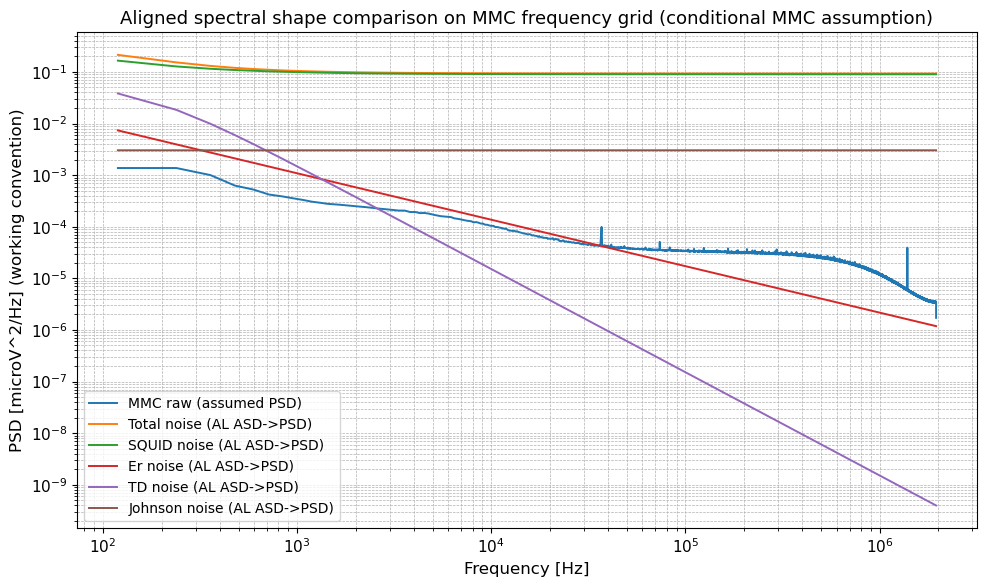

In [35]:
print("Conditional MMC comparison assumptions:")
print("- MMC raw .npy values are assumed to be PSD (not ASD)")
print("- MMC raw spectrum is assumed one-sided")
print("- MMC raw PSD unit is assumed microV^2/Hz")

print("\nAligned integrated PSD comparison (variance in microV^2, RMS in microV):")
for label, variance, rms, finite_bins_used in aligned_results:
    print(f"{label}: variance={variance:.6f}, rms={rms:.6f}")

print("\nRelative to MMC variance under the working assumption:")
for label, variance, rms, finite_bins_used in aligned_results[1:]:
    print(
        f"{label}: variance/MMC={variance / mmc_variance_microvolt2_assumed:.6g}, "
        f"rms/MMC={rms / np.sqrt(mmc_variance_microvolt2_assumed):.6g}"
    )

print("\nMMC variance if raw .npy were larger prefix units instead:")
print(f"- If raw MMC is mV^2/Hz, variance in microV^2 would be {mmc_variance_microvolt2_assumed * 1e6:.6f}")
print(f"- If raw MMC is V^2/Hz, variance in microV^2 would be {mmc_variance_microvolt2_assumed * 1e12:.6f}")

plt.figure(figsize=(10, 6))
for label, psd_values in aligned_psd_map.items():
    valid = (common_freq > 0) & np.isfinite(psd_values) & (psd_values > 0)
    plt.loglog(common_freq[valid], psd_values[valid], label=label, linewidth=1.4)
plt.title("Aligned spectral shape comparison on MMC frequency grid (conditional MMC assumption)")
plt.xlabel("Frequency [Hz]")
plt.ylabel("PSD [microV^2/Hz] (working convention)")
plt.grid(True, which="both", linestyle="--", linewidth=0.5)
plt.legend()
plt.tight_layout()
plt.show()


## Provisional MMC-Aligned Integrated Variance Summary

This section reports integrated variance over the aligned frequency band, computed by numerical trapezoidal integration of the PSD.


In [36]:
def cumulative_variance_fraction(frequencies, psd_values, cutoff_hz):
    valid = (frequencies > 0) & np.isfinite(psd_values) & (psd_values >= 0)
    f = frequencies[valid]
    p = psd_values[valid]
    total = np.trapz(p, f)
    if total <= 0:
        return np.nan
    below = f <= cutoff_hz
    if np.count_nonzero(below) < 2:
        return 0.0
    return np.trapz(p[below], f[below]) / total


cutoffs_hz = [1e3, 1e4, 1e5]
print("Cumulative variance fractions and dominance class (still conditional on MMC assumptions):")
for label, psd_values in aligned_psd_map.items():
    frac_1k = cumulative_variance_fraction(common_freq, psd_values, 1e3)
    frac_10k = cumulative_variance_fraction(common_freq, psd_values, 1e4)
    frac_100k = cumulative_variance_fraction(common_freq, psd_values, 1e5)
    dominance = "low-frequency dominated" if np.isfinite(frac_10k) and frac_10k >= 0.5 else "broadband dominated"
    print(f"{label}: f<1kHz={frac_1k:.6f}, f<10kHz={frac_10k:.6f}, f<100kHz={frac_100k:.6f}, class={dominance}")


Cumulative variance fractions and dominance class (still conditional on MMC assumptions):
MMC raw (assumed PSD): f<1kHz=0.018759, f<10kHz=0.066342, f<100kHz=0.185051, class=broadband dominated
Total noise (AL ASD->PSD): f<1kHz=0.000587, f<10kHz=0.005301, f<100kHz=0.051492, class=broadband dominated
SQUID noise (AL ASD->PSD): f<1kHz=0.000537, f<10kHz=0.005233, f<100kHz=0.051412, class=broadband dominated
Er noise (AL ASD->PSD): f<1kHz=0.144586, f<10kHz=0.341811, f<100kHz=0.587664, class=broadband dominated
TD noise (AL ASD->PSD): f<1kHz=0.826866, f<10kHz=0.983278, f<100kHz=0.998420, class=low-frequency dominated
Johnson noise (AL ASD->PSD): f<1kHz=0.000427, f<10kHz=0.005005, f<100kHz=0.051090, class=broadband dominated


## Notes on Verified Facts vs Assumptions

### Verified facts

- AL files (`total_noise.dat`, `SQUID_noise.dat`, `Er_noise.dat`, `TD_noise.dat`, `Johnson_noise.dat`) are interpreted as ASD from the professor's y-axis label sqrt(S_phi) / microPhi0 / sqrt(Hz).
- AL variance is computed only after ASD -> PSD conversion: square ASD to obtain PSD, then perform numerical trapezoidal integration of the PSD over frequency.
- AL component quadrature check is explicitly validated on the native AL grid before MMC alignment.

### Assumed for provisional MMC-inclusive comparison

- MMC raw `.npy` values are PSD (not ASD).
- MMC raw PSD is one-sided.
- MMC stored scale is microV^2/Hz.

Any MMC-inclusive integrated variance over the aligned frequency band remains provisional until these MMC assumptions are verified upstream.
